In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import random

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [54]:
X_train = x_train/255.0
X_test = x_test/255.0

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

d:\Programming\my_python\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [58]:
model.compile(optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy,
    metrics=['accuracy']
)

In [65]:
training = model.fit(X_train, y_train, epochs=8)

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9861 - loss: 0.0466
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9869 - loss: 0.0428
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9880 - loss: 0.0396
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9890 - loss: 0.0365
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9896 - loss: 0.0337
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9907 - loss: 0.0308
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9912 - loss: 0.0291
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9919 - loss: 0.0265


In [56]:
predictions = model.predict(X_test)
print(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[6.5889285e-06 2.1234197e-07 2.9577091e-04 1.4665908e-03 5.8947447e-09
 6.0412167e-06 6.0386331e-13 9.9817324e-01 1.5979986e-05 3.5576228e-05]


In [70]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

predicted = np.argmax(predictions)
actual = y_test

print(f"Model Predicts: {predicted}")
print(f"Actual Number: {actual}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9705 - loss: 0.1149
Final Test Accuracy: 97.05%
Model Predicts: 2960
Actual Number: [7 2 1 ... 4 5 6]


2818
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


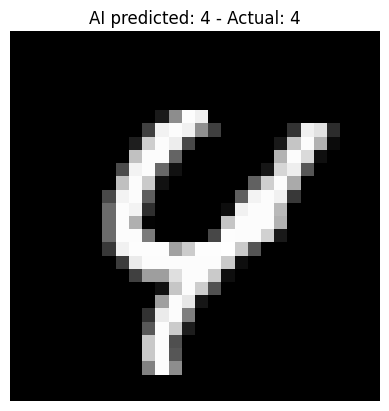

Confidence Level: 100.00%


In [76]:
random_idx = random.randint(0, len(X_test) - 1)
print(random_idx)

img_idx = X_test[random_idx]
lbl_idx = y_test[random_idx]

predictions_probs = model.predict(img_idx.reshape(1, 28, 28))
predicted_label = np.argmax(predictions_probs)

plt.imshow(img_idx, cmap='gray')
plt.title(f"AI predicted: {predicted_label} - Actual: {lbl_idx}")
plt.axis('off')
plt.show()

confidence = predictions_probs[0][predicted_label]
print(f"Confidence Level: {confidence * 100:.2f}%")